# Project: Customer Sales & Churn Tracker

Objective :
The objective of this project is to transform raw, inconsistent retail transaction logs into actionable intelligence. By applying professional data cleaning techniques and behavioral analysis, we aim to:
1.Clean:Address missing values, anomalies, and inconsistencies to ensure a reliable dataset.
2.Segment Customers:Utilize RFM (Recency, Frequency, Monetary) analysis to identify high-value vs. at-risk customer segments.
3.Predict Churn:Develop a predictive classification model to identify customers at risk of abandonment, enabling proactive retention strategies.

# Project Roadmap
1.Data Cleaning :
   Handling missing IDs and null values.
   Cleaning data types and correcting format inconsistencies.
   Separating returns from standard sales.

2.Exploratory Data Analysis:
   Visualizing sales trends and customer behavior.
   Identifying key KPIs (Key Performance Indicators).

3.Customer Segmentation:
   Feature engineering for RFM metrics.
   Clustering customers based on engagement levels.

4.Predictive Modeling:
   Training a classification model for churn detection.
   Evaluating model performance and business impact.


In [21]:
#Importing Libraries
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


In [22]:
#Loading the dataset
# Fixing the spelling and the encoding
retail_data= pd.read_csv("Dataset/online_retail.csv", encoding='ISO-8859-1')

# Now check the data structure
print(retail_data.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None


In [23]:
# DATA CLEANNG
# 1. Drop rows where CustomerID is missing
retail_clean = retail_data.dropna(subset=['CustomerID']).copy()

# 2. Convert InvoiceDate to datetime objects (Essential for time-based analysis)
retail_clean['InvoiceDate'] = pd.to_datetime(retail_clean['InvoiceDate'])

# 3. Check for negative quantities (these are returned orders)
# We want to see how many there are before we decide how to handle them
returns_count = retail_clean[retail_clean['Quantity'] < 0].shape[0]
print(f"Number of return transactions: {returns_count}")

# Show the new shape of your data
print(f"Original shape: {retail_data.shape}")
print(f"Cleaned shape: {retail_clean.shape}")


Number of return transactions: 8905
Original shape: (541909, 8)
Cleaned shape: (406829, 8)


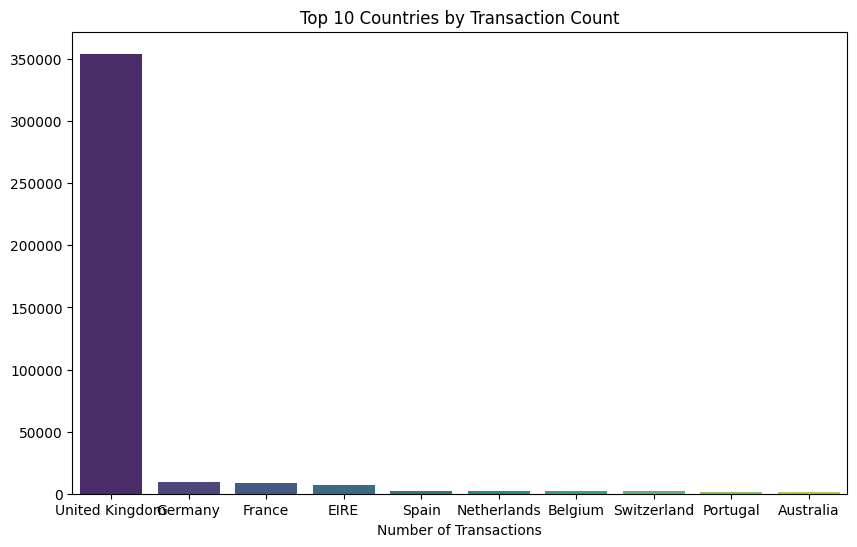

Total Revenue in our cleaned dataset: $8,911,407.90


In [24]:
#EXPLORATORY DATA ANALYSIS

# 1. Filter out the returns for our "Sales" analysis
sales_data = retail_clean[retail_clean['Quantity'] > 0]

# 2. Visualize top 10 countries by transaction count
plt.figure(figsize=(10, 6))
top_countries = sales_data['Country'].value_counts().head(10)
sns.barplot(y=top_countries.values, x=top_countries.index, palette='viridis',hue=top_countries.index, legend=False)
plt.title('Top 10 Countries by Transaction Count')
plt.xlabel('Number of Transactions')
plt.show()

# 3. Quick check of total revenue per transaction
sales_data = sales_data.copy()
sales_data['TotalRevenue'] = sales_data['Quantity'] * sales_data['UnitPrice']
print(f"Total Revenue in our cleaned dataset: ${sales_data['TotalRevenue'].sum():,.2f}")


In [25]:
#Customer Segmentation using RFM strategy

# 1. Calculate the latest date in the dataset to calculate 'Recency'
latest_date = sales_data['InvoiceDate'].max()

# 2. Group by CustomerID and calculate R, F, and M
rfm = sales_data.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (latest_date - x.max()).days, # Recency
    'InvoiceNo': 'count',                                  # Frequency
    'TotalRevenue': 'sum'                                  # Monetary
})

# 3. Rename columns for clarity
rfm.rename(columns={'InvoiceDate': 'Recency', 'InvoiceNo': 'Frequency', 'TotalRevenue': 'Monetary'}, inplace=True)

# 4. Take a look at your new segments!
print(rfm.head())


            Recency  Frequency  Monetary
CustomerID                              
12346.0         325          1  77183.60
12347.0           1        182   4310.00
12348.0          74         31   1797.24
12349.0          18         73   1757.55
12350.0         309         17    334.40


In [26]:
# Create quartiles for ranking
# Use qcut to automatically create 4 bins (1-4)
# We use labels=[4, 3, 2, 1] for Recency because lower is better (more recent)
# We use labels=[1, 2, 3, 4] for Frequency/Monetary because higher is better
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1, 2, 3, 4])


In [27]:
# Combine to create a single score string
rfm['RFM_Group'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# Calculate a numeric sum for easy sorting (higher is better)
rfm['RFM_Score'] = rfm[['R_Score', 'F_Score', 'M_Score']].sum(axis=1)

# Print a professional summary
print("RFM Analysis Summary:")
print(f"Average RFM Score: {rfm['RFM_Score'].mean():.2f}")
print(f"Top 5 Customers by RFM Score:\n{rfm.sort_values('RFM_Score', ascending=False).head(5)}")



RFM Analysis Summary:
Average RFM Score: 7.51
Top 5 Customers by RFM Score:
            Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Group  \
CustomerID                                                                   
15544.0           8        259   3546.71       4       4       4       444   
14554.0           9        216   2381.04       4       4       4       444   
16327.0          13        319   3844.22       4       4       4       444   
13098.0           0        572  28882.44       4       4       4       444   
17629.0           5        123   1814.12       4       4       4       444   

            RFM_Score  
CustomerID             
15544.0            12  
14554.0            12  
16327.0            12  
13098.0            12  
17629.0            12  


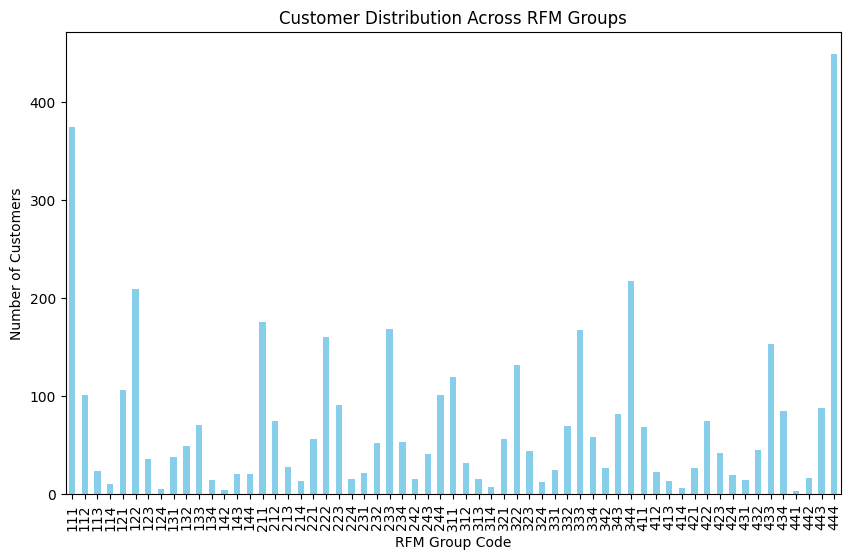

In [28]:
# Visualize the segments
# Instead of rfm['Segment'], use the column that actually exists now
plt.figure(figsize=(10, 6))
rfm['RFM_Group'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Customer Distribution Across RFM Groups')
plt.xlabel('RFM Group Code')
plt.ylabel('Number of Customers')
plt.show()


In [29]:
#Predicting the customers who might churn

# Create a 'Churn' column: 1 if Recency > 90 days, else 0
rfm['Churn'] = rfm['Recency'].apply(lambda x: 1 if x > 90 else 0)


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Features (X) and Target (y)
X = rfm[['Frequency', 'Monetary']]
y = rfm['Churn']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)
model.fit(X_train, y_train)

# Evaluate
predictions = model.predict(X_test)
print(classification_report(y_test, predictions))


              precision    recall  f1-score   support

           0       0.79      0.75      0.77       569
           1       0.57      0.62      0.59       299

    accuracy                           0.71       868
   macro avg       0.68      0.68      0.68       868
weighted avg       0.71      0.71      0.71       868




# Model Performance Summary:
1.Precision (0.57 for Churners): When our model predicts a customer will churn, it is correct 57% of the time. This helps marketing avoid wasting budget on customers who are actually loyal.

2.Recall (0.62 for Churners): Our model successfully captures 62% of all actual churners. This allows the business to proactively reach out to at-risk customers before they leave.

3.F1-Score (0.59): This represents the balance between precision and recall, indicating a reliable model for identifying churn-risk candidates.

4.Accuracy (0.71): This represents the overall performance of the model across both churned and loyal customers. While accuracy is a useful general benchmark, the F1-score provides a more honest assessment of our ability to specifically target the minority 'churn' class in this imbalanced dataset